# QE-HF4 results

**Quantification workflow:** DDA  
**Preprocessing profile:** `dda_missingness_v1`

The VAE is trained on good QC samples, and the MLP classifies good and bad samples from the eight-dimensional VAE latent mean. The table below reports the five folds used in the manuscript analysis.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

cwd = Path.cwd().resolve()
project_root = next(
    (
        candidate
        for candidate in [cwd, *cwd.parents]
        if (candidate / "results" / "summary_metrics.csv").exists()
    ),
    None,
)
if project_root is None:
    raise RuntimeError("Run this notebook from inside the project repository.")


In [2]:
summary = pd.read_csv(project_root / 'results' / 'summary_metrics.csv')
folds = pd.read_csv(project_root / 'results' / 'cv_metrics.csv')
display(summary[summary['instrument'] == 'qe_hf4'].round(4))
display(folds[folds['instrument'] == 'qe_hf4'].round(4))

,instrument,quantification,n_samples,n_good,n_bad,auc_mean,auc_sd,accuracy_mean,f1_bad_mean
4,qe_hf4,DDA,120,75,45,0.974,0.0179,0.9664,0.954


,instrument,quantification,fold,auc,accuracy,precision_bad,recall_bad,specificity_good,f1_bad,threshold
20,qe_hf4,DDA,1,0.963,0.958,1.0,0.889,1.000,0.941,0.7982
21,qe_hf4,DDA,2,0.974,0.958,0.9,1.000,0.933,0.947,0.9753
22,qe_hf4,DDA,3,1.000,1.000,1.0,1.000,1.000,1.000,1.0000
23,qe_hf4,DDA,4,0.948,0.958,1.0,0.889,1.000,0.941,0.9302
24,qe_hf4,DDA,5,0.985,0.958,1.0,0.889,1.000,0.941,0.9992


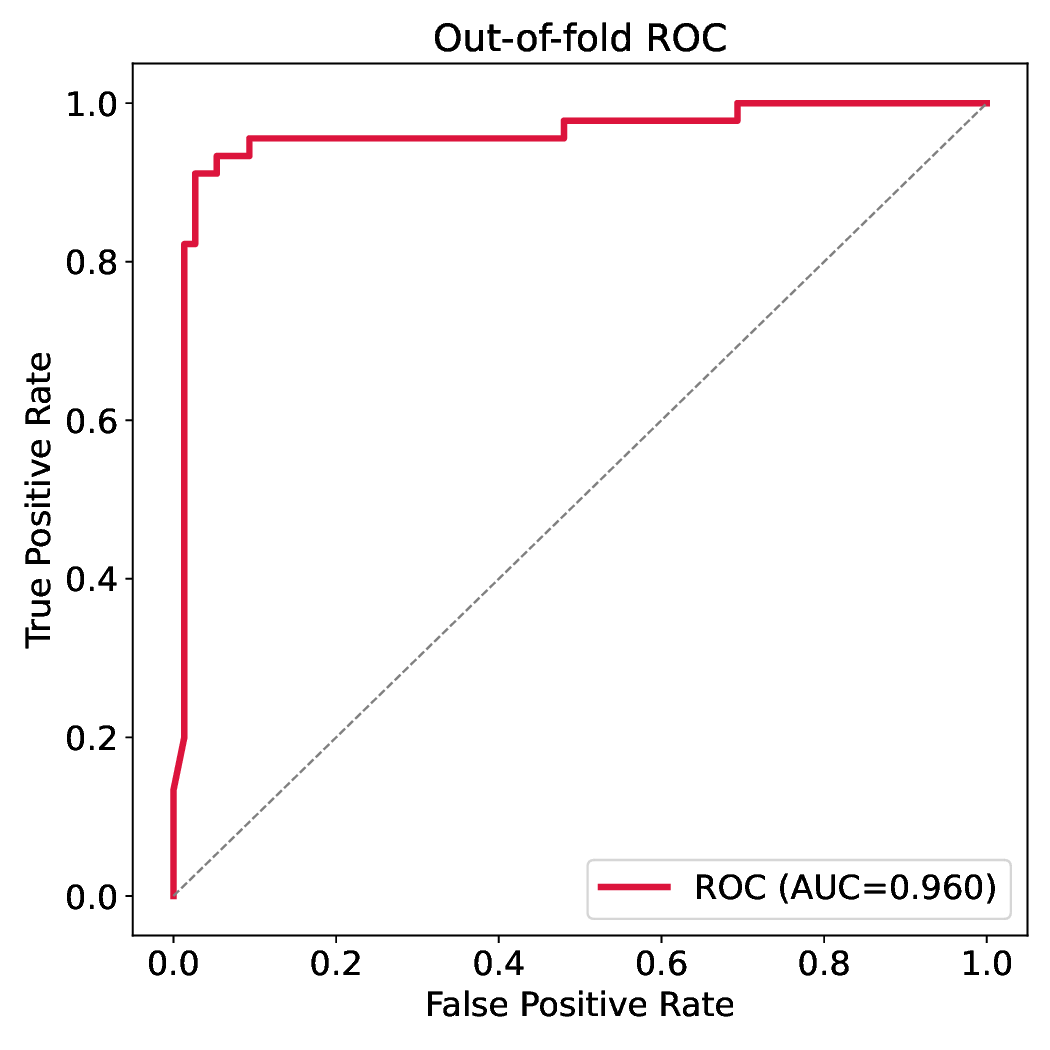

In [3]:
display(Image(filename=project_root / 'results' / 'figures' / 'roc' / 'qe_hf4_roc.png'))

## Reuse

The pretrained checkpoint is distributed as `qe_hf4.pt` with the data and model archive. See the repository README for download and inference commands.